# NBA Expected Points (xPTS) - Player-Specific Model

This notebook builds a **player-specific public-data NBA expected points (xPTS)** model using shot-level data from `nba_api` (`ShotChartDetail`) plus aggregate player shooting profile splits from `PlayerDashPtShots`.

For each shot attempt, we estimate make probability and convert it to expected points:

\[
xPTS = \hat{P}(\text{make}) \times \text{shot\_value}
\]

where `shot_value` is 2 for two-point attempts and 3 for three-point attempts.

The model target is `SHOT_MADE_FLAG`. Predicted probabilities are interpreted as player-specific `xfg_pct_player_specific` and converted to `xpts_player_specific`.

This notebook is structured as a reproducible data science workflow with:
- robust data collection + CSV fallback,
- leakage-safe player prior smoothing from training seasons only,
- baseline and stronger probability models,
- player-specific xPTS outputs,
- game-level actual vs expected shot-scoring flow.

## 1) Imports

In [1]:
from pathlib import Path
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, brier_score_loss
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve

from nba_api.stats.endpoints import shotchartdetail, playerdashptshots
from nba_api.stats.static import teams

from xgboost import XGBClassifier

import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)



## 2) Config

In [2]:
SEASONS = ["2021-22", "2022-23", "2023-24", "2024-25", "2025-26"]
SEASON_TYPE = "Regular Season"
RANDOM_SEED = 42

PROJECT_ROOT = Path(".").resolve()
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

RAW_PATH = RAW_DATA_PATH / "shotchart_shots.csv"
PLAYER_DASH_CLOSEST_PATH = RAW_DATA_PATH / "playerdashptshots_closest_defender.csv"
PLAYER_DASH_CLOSEST_10P_PATH = RAW_DATA_PATH / "playerdashptshots_closest_defender_10ft_plus.csv"
PREDS_PATH = PROCESSED_DATA_PATH / "xpts_player_specific_predictions.csv"
MODEL_PATH = MODELS_DIR / "xpts_player_specific_model.pkl"

for p in [RAW_DATA_PATH, PROCESSED_DATA_PATH, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_PATH:", RAW_PATH)
print("PLAYER_DASH_CLOSEST_PATH:", PLAYER_DASH_CLOSEST_PATH)
print("PLAYER_DASH_CLOSEST_10P_PATH:", PLAYER_DASH_CLOSEST_10P_PATH)
print("PREDS_PATH:", PREDS_PATH)
print("MODEL_PATH:", MODEL_PATH)

PROJECT_ROOT: /Users/qaischatur/Documents/nba-xpts
RAW_PATH: /Users/qaischatur/Documents/nba-xpts/data/raw/shotchart_shots.csv
PLAYER_DASH_CLOSEST_PATH: /Users/qaischatur/Documents/nba-xpts/data/raw/playerdashptshots_closest_defender.csv
PLAYER_DASH_CLOSEST_10P_PATH: /Users/qaischatur/Documents/nba-xpts/data/raw/playerdashptshots_closest_defender_10ft_plus.csv
PREDS_PATH: /Users/qaischatur/Documents/nba-xpts/data/processed/xpts_player_specific_predictions.csv
MODEL_PATH: /Users/qaischatur/Documents/nba-xpts/models/xpts_player_specific_model.pkl


## 3) Data Collection from `nba_api` (`ShotChartDetail`)

In [3]:
KEEP_COLS = [
    "GAME_ID", "GAME_EVENT_ID", "PLAYER_ID", "PLAYER_NAME", "TEAM_ID", "TEAM_NAME",
    "PERIOD", "MINUTES_REMAINING", "SECONDS_REMAINING", "EVENT_TYPE", "ACTION_TYPE",
    "SHOT_TYPE", "SHOT_ZONE_BASIC", "SHOT_ZONE_AREA", "SHOT_ZONE_RANGE", "SHOT_DISTANCE",
    "LOC_X", "LOC_Y", "SHOT_MADE_FLAG", "GAME_DATE", "HTM", "VTM"
]


def fetch_shots_for_season_all(season: str, season_type: str = "Regular Season") -> pd.DataFrame:
    """Attempt a season-wide pull with team_id=0, player_id=0."""
    try:
        endpoint = shotchartdetail.ShotChartDetail(
            team_id=0,
            player_id=0,
            context_measure_simple="FGA",
            season_nullable=season,
            season_type_all_star=season_type,
            timeout=60,
        )
        df = endpoint.get_data_frames()[0].copy()
        df["SEASON"] = season
        return df
    except Exception as e:
        print(f"Season-wide pull failed for {season}: {e}")
        return pd.DataFrame()


def fetch_shots_for_season_team_by_team(
    season: str,
    season_type: str = "Regular Season",
    sleep_seconds: float = 0.7,
) -> pd.DataFrame:
    """Fallback pull by looping over teams from nba_api.stats.static.teams."""
    team_rows = teams.get_teams()
    season_frames = []

    for i, t in enumerate(team_rows, start=1):
        team_id = t["id"]
        team_name = t["full_name"]
        try:
            endpoint = shotchartdetail.ShotChartDetail(
                team_id=team_id,
                player_id=0,
                context_measure_simple="FGA",
                season_nullable=season,
                season_type_all_star=season_type,
                timeout=60,
            )
            df_t = endpoint.get_data_frames()[0].copy()
            df_t["SEASON"] = season
            season_frames.append(df_t)
            print(f"[{season}] {i:02d}/{len(team_rows)} pulled {team_name}: {len(df_t):,} rows")
        except Exception as e:
            print(f"[{season}] failed {team_name}: {e}")
        time.sleep(sleep_seconds)

    if not season_frames:
        return pd.DataFrame()
    return pd.concat(season_frames, ignore_index=True)


def collect_shotchart_data(
    seasons,
    season_type: str = "Regular Season",
    prefer_all_league_first: bool = True,
    sleep_seconds: float = 0.7,
) -> pd.DataFrame:
    """Reusable shot collection with season-wide then team-by-team fallback."""
    season_frames = []

    for season in seasons:
        print(f"\nCollecting season {season}...")
        df_season = pd.DataFrame()

        if prefer_all_league_first:
            df_season = fetch_shots_for_season_all(season, season_type)

        if df_season.empty:
            print(f"Falling back to team-by-team pull for {season}")
            df_season = fetch_shots_for_season_team_by_team(
                season=season,
                season_type=season_type,
                sleep_seconds=sleep_seconds,
            )

        if df_season.empty:
            print(f"No data collected for {season}")
            continue

        cols = [c for c in KEEP_COLS if c in df_season.columns]
        if "SEASON" in df_season.columns:
            cols += ["SEASON"]
        df_season = df_season[cols].copy()

        season_frames.append(df_season)
        print(f"Finished {season}: {len(df_season):,} rows")

    if not season_frames:
        raise RuntimeError("No shot data could be collected from nba_api.")

    shots = pd.concat(season_frames, ignore_index=True)
    shots = shots.drop_duplicates(subset=["GAME_ID", "GAME_EVENT_ID", "PLAYER_ID", "TEAM_ID"])
    return shots

## 4) Data Loading Fallback

If `data/raw/shotchart_shots.csv` exists, we load it directly. Otherwise, we pull from `nba_api` and save it.

In [4]:
if RAW_PATH.exists():
    print(f"Loading existing shot-level raw data: {RAW_PATH}")
    shots_raw = pd.read_csv(RAW_PATH)
else:
    print("Raw shot CSV not found. Pulling from nba_api...")
    shots_raw = collect_shotchart_data(
        seasons=SEASONS,
        season_type=SEASON_TYPE,
        prefer_all_league_first=True,
        sleep_seconds=0.7,
    )
    shots_raw.to_csv(RAW_PATH, index=False)
    print(f"Saved shot-level raw data to {RAW_PATH}")

print("Raw shots shape:", shots_raw.shape)
print("Raw shots columns:", shots_raw.columns.tolist())
print("Raw shots preview (first 10 rows):")
display(shots_raw.head(10))


Loading existing shot-level raw data: /Users/qaischatur/Documents/nba-xpts/data/raw/shotchart_shots.csv
Raw shots shape: (540627, 23)
Raw shots columns: ['GAME_ID', 'GAME_EVENT_ID', 'PLAYER_ID', 'PLAYER_NAME', 'TEAM_ID', 'TEAM_NAME', 'PERIOD', 'MINUTES_REMAINING', 'SECONDS_REMAINING', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE', 'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'SHOT_DISTANCE', 'LOC_X', 'LOC_Y', 'SHOT_MADE_FLAG', 'GAME_DATE', 'HTM', 'VTM', 'SEASON']
Raw shots preview (first 10 rows):


,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,SEASON
0,22200001,7,203954,Joel Embiid,1610612755,Philadelphia 76ers,1,11,38,Missed Shot,Turnaround Fadeaway shot,2PT Field Goal,Mid-Range,Left Side(L),8-16 ft.,12,-118,50,0,20221018,BOS,PHI,2022-23
1,22200001,11,203935,Marcus Smart,1610612738,Boston Celtics,1,11,15,Made Shot,Driving Floating Bank Jump Shot,2PT Field Goal,Mid-Range,Right Side(R),8-16 ft.,13,120,55,1,20221018,BOS,PHI,2022-23
2,22200001,12,202699,Tobias Harris,1610612755,Philadelphia 76ers,1,11,5,Missed Shot,Driving Floating Jump Shot,2PT Field Goal,In The Paint (Non-RA),Center(C),8-16 ft.,14,50,135,0,20221018,BOS,PHI,2022-23
3,22200001,14,202699,Tobias Harris,1610612755,Philadelphia 76ers,1,11,3,Made Shot,Tip Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,0,0,0,1,20221018,BOS,PHI,2022-23
4,22200001,15,1628369,Jayson Tatum,1610612738,Boston Celtics,1,10,46,Made Shot,Jump Shot,3PT Field Goal,Left Corner 3,Left Side(L),24+ ft.,23,-232,49,1,20221018,BOS,PHI,2022-23
5,22200001,17,203954,Joel Embiid,1610612755,Philadelphia 76ers,1,10,33,Missed Shot,Jump Shot,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,26,116,241,0,20221018,BOS,PHI,2022-23
6,22200001,23,1630178,Tyrese Maxey,1610612755,Philadelphia 76ers,1,10,12,Missed Shot,Driving Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,3,38,8,0,20221018,BOS,PHI,2022-23
7,22200001,27,202699,Tobias Harris,1610612755,Philadelphia 76ers,1,10,9,Missed Shot,Fadeaway Jump Shot,2PT Field Goal,In The Paint (Non-RA),Center(C),8-16 ft.,12,31,121,0,20221018,BOS,PHI,2022-23
8,22200001,29,1628401,Derrick White,1610612738,Boston Celtics,1,10,4,Missed Shot,Running Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,1,-10,12,0,20221018,BOS,PHI,2022-23
9,22200001,35,201143,Al Horford,1610612738,Boston Celtics,1,9,53,Missed Shot,Cutting Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,2,20,10,0,20221018,BOS,PHI,2022-23


## 5) PlayerDashPtShots Collection (Player Profile Splits)

These are **aggregate player split tables**, not shot-by-shot defender distance. We use them only as player profile priors.

In [5]:
def _safe_pick_playerdash_table(dfs: list[pd.DataFrame], candidate_columns: list[str]) -> pd.DataFrame:
    """Pick the first non-empty dataframe containing all candidate columns."""
    for d in dfs:
        if isinstance(d, pd.DataFrame) and (not d.empty) and all(c in d.columns for c in candidate_columns):
            return d.copy()
    return pd.DataFrame()


def fetch_player_dash_pt_shots_for_season(season: str, season_type: str = "Regular Season"):
    """
    Pull player aggregate shooting splits for a season.
    Returns a dict with at minimum closest defender tables when available.
    """
    out = {
        "closest_defender": pd.DataFrame(),
        "closest_defender_10ft_plus": pd.DataFrame(),
        "general_shooting": pd.DataFrame(),
        "dribble_shooting": pd.DataFrame(),
        "touch_time_shooting": pd.DataFrame(),
        "shot_clock_shooting": pd.DataFrame(),
    }

    try:
        ep = playerdashptshots.PlayerDashPtShots(
            team_id=0,
            player_id=0,
            season=season,
            season_type_all_star=season_type,
            per_mode_simple="Totals",
            timeout=60,
        )
        try:
            out["closest_defender"] = ep.closest_defender_shooting.get_data_frame().copy()
        except Exception:
            pass

        try:
            out["closest_defender_10ft_plus"] = ep.closest_defender10ft_plus_shooting.get_data_frame().copy()
        except Exception:
            pass

        # Fallback to dataframe sniffing if named result sets are unavailable.
        dfs = ep.get_data_frames()
        if out["closest_defender"].empty:
            out["closest_defender"] = _safe_pick_playerdash_table(
                dfs, ["PLAYER_ID", "PLAYER_NAME", "CLOSE_DEF_DIST_RANGE", "FGM", "FGA"]
            )
        if out["closest_defender_10ft_plus"].empty:
            # pick a second candidate table with same schema but different row count when possible
            candidates = [d for d in dfs if isinstance(d, pd.DataFrame) and (not d.empty) and all(c in d.columns for c in ["PLAYER_ID", "PLAYER_NAME", "CLOSE_DEF_DIST_RANGE", "FGM", "FGA"])]
            if len(candidates) >= 2:
                out["closest_defender_10ft_plus"] = candidates[1].copy()
            elif len(candidates) == 1:
                out["closest_defender_10ft_plus"] = candidates[0].copy()

        # Optional tables when exposed
        try:
            out["general_shooting"] = ep.general_shooting.get_data_frame().copy()
        except Exception:
            pass
        try:
            out["dribble_shooting"] = ep.dribble_shooting.get_data_frame().copy()
        except Exception:
            pass
        try:
            out["touch_time_shooting"] = ep.touch_time_shooting.get_data_frame().copy()
        except Exception:
            pass
        try:
            out["shot_clock_shooting"] = ep.shot_clock_shooting.get_data_frame().copy()
        except Exception:
            pass

        for k in out:
            if not out[k].empty:
                out[k]["SEASON"] = season

    except Exception as e:
        print(f"PlayerDashPtShots failed for {season}: {e}")

    return out


def collect_player_dash_pt_shots(seasons, season_type: str = "Regular Season"):
    all_cd, all_cd10 = [], []

    for season in seasons:
        print(f"Collecting PlayerDashPtShots for {season}...")
        payload = fetch_player_dash_pt_shots_for_season(season, season_type)

        cd = payload.get("closest_defender", pd.DataFrame())
        cd10 = payload.get("closest_defender_10ft_plus", pd.DataFrame())

        if not cd.empty:
            all_cd.append(cd)
        if not cd10.empty:
            all_cd10.append(cd10)

    closest_defender = pd.concat(all_cd, ignore_index=True) if all_cd else pd.DataFrame()
    closest_defender_10ft_plus = pd.concat(all_cd10, ignore_index=True) if all_cd10 else pd.DataFrame()

    return closest_defender, closest_defender_10ft_plus


# CSV fallback for player profile split data
if PLAYER_DASH_CLOSEST_PATH.exists() and PLAYER_DASH_CLOSEST_10P_PATH.exists():
    print("Loading existing PlayerDashPtShots CSVs...")
    player_dash_closest = pd.read_csv(PLAYER_DASH_CLOSEST_PATH)
    player_dash_closest_10p = pd.read_csv(PLAYER_DASH_CLOSEST_10P_PATH)
else:
    print("PlayerDashPtShots CSVs not found. Pulling from nba_api...")
    player_dash_closest, player_dash_closest_10p = collect_player_dash_pt_shots(SEASONS, SEASON_TYPE)

    if not player_dash_closest.empty:
        player_dash_closest.to_csv(PLAYER_DASH_CLOSEST_PATH, index=False)
        print(f"Saved {PLAYER_DASH_CLOSEST_PATH}")
    else:
        print("ClosestDefenderShooting unavailable; continuing without it.")

    if not player_dash_closest_10p.empty:
        player_dash_closest_10p.to_csv(PLAYER_DASH_CLOSEST_10P_PATH, index=False)
        print(f"Saved {PLAYER_DASH_CLOSEST_10P_PATH}")
    else:
        print("ClosestDefender10ftPlusShooting unavailable; continuing without it.")

print("player_dash_closest shape:", player_dash_closest.shape)
print("player_dash_closest_10p shape:", player_dash_closest_10p.shape)


Loading existing PlayerDashPtShots CSVs...
player_dash_closest shape: (11011, 20)
player_dash_closest_10p shape: (9437, 20)


In [6]:
shots_raw.head()

,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,SEASON
0,22200001,7,203954,Joel Embiid,1610612755,Philadelphia 76ers,1,11,38,Missed Shot,Turnaround Fadeaway shot,2PT Field Goal,Mid-Range,Left Side(L),8-16 ft.,12,-118,50,0,20221018,BOS,PHI,2022-23
1,22200001,11,203935,Marcus Smart,1610612738,Boston Celtics,1,11,15,Made Shot,Driving Floating Bank Jump Shot,2PT Field Goal,Mid-Range,Right Side(R),8-16 ft.,13,120,55,1,20221018,BOS,PHI,2022-23
2,22200001,12,202699,Tobias Harris,1610612755,Philadelphia 76ers,1,11,5,Missed Shot,Driving Floating Jump Shot,2PT Field Goal,In The Paint (Non-RA),Center(C),8-16 ft.,14,50,135,0,20221018,BOS,PHI,2022-23
3,22200001,14,202699,Tobias Harris,1610612755,Philadelphia 76ers,1,11,3,Made Shot,Tip Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,0,0,0,1,20221018,BOS,PHI,2022-23
4,22200001,15,1628369,Jayson Tatum,1610612738,Boston Celtics,1,10,46,Made Shot,Jump Shot,3PT Field Goal,Left Corner 3,Left Side(L),24+ ft.,23,-232,49,1,20221018,BOS,PHI,2022-23


## 5) Initial Data Inspection

In [7]:
print("Shape:", shots_raw.shape)
print("\nColumns:")
print(sorted(shots_raw.columns.tolist()))

print("\nMissing values (top 20):")
print(shots_raw.isna().sum().sort_values(ascending=False).head(20))

print("\nSample rows:")
display(shots_raw.head())

print("\nSHOT_MADE_FLAG distribution:")
if "SHOT_MADE_FLAG" in shots_raw.columns:
    display(shots_raw["SHOT_MADE_FLAG"].value_counts(dropna=False).rename("count"))

print("\nSHOT_TYPE distribution:")
if "SHOT_TYPE" in shots_raw.columns:
    display(shots_raw["SHOT_TYPE"].value_counts(dropna=False).head(10).rename("count"))

print("\nTop ACTION_TYPE values:")
if "ACTION_TYPE" in shots_raw.columns:
    display(shots_raw["ACTION_TYPE"].value_counts(dropna=False).head(15).rename("count"))

print("\nTop SHOT_ZONE_BASIC values:")
if "SHOT_ZONE_BASIC" in shots_raw.columns:
    display(shots_raw["SHOT_ZONE_BASIC"].value_counts(dropna=False).head(15).rename("count"))

Shape: (540627, 23)

Columns:
['ACTION_TYPE', 'EVENT_TYPE', 'GAME_DATE', 'GAME_EVENT_ID', 'GAME_ID', 'HTM', 'LOC_X', 'LOC_Y', 'MINUTES_REMAINING', 'PERIOD', 'PLAYER_ID', 'PLAYER_NAME', 'SEASON', 'SECONDS_REMAINING', 'SHOT_DISTANCE', 'SHOT_MADE_FLAG', 'SHOT_TYPE', 'SHOT_ZONE_AREA', 'SHOT_ZONE_BASIC', 'SHOT_ZONE_RANGE', 'TEAM_ID', 'TEAM_NAME', 'VTM']

Missing values (top 20):
GAME_ID              0
SHOT_ZONE_BASIC      0
VTM                  0
HTM                  0
GAME_DATE            0
SHOT_MADE_FLAG       0
LOC_Y                0
LOC_X                0
SHOT_DISTANCE        0
SHOT_ZONE_RANGE      0
SHOT_ZONE_AREA       0
SHOT_TYPE            0
GAME_EVENT_ID        0
ACTION_TYPE          0
EVENT_TYPE           0
SECONDS_REMAINING    0
MINUTES_REMAINING    0
PERIOD               0
TEAM_NAME            0
TEAM_ID              0
dtype: int64

Sample rows:


,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,EVENT_TYPE,ACTION_TYPE,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,SEASON
0,22200001,7,203954,Joel Embiid,1610612755,Philadelphia 76ers,1,11,38,Missed Shot,Turnaround Fadeaway shot,2PT Field Goal,Mid-Range,Left Side(L),8-16 ft.,12,-118,50,0,20221018,BOS,PHI,2022-23
1,22200001,11,203935,Marcus Smart,1610612738,Boston Celtics,1,11,15,Made Shot,Driving Floating Bank Jump Shot,2PT Field Goal,Mid-Range,Right Side(R),8-16 ft.,13,120,55,1,20221018,BOS,PHI,2022-23
2,22200001,12,202699,Tobias Harris,1610612755,Philadelphia 76ers,1,11,5,Missed Shot,Driving Floating Jump Shot,2PT Field Goal,In The Paint (Non-RA),Center(C),8-16 ft.,14,50,135,0,20221018,BOS,PHI,2022-23
3,22200001,14,202699,Tobias Harris,1610612755,Philadelphia 76ers,1,11,3,Made Shot,Tip Layup Shot,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,0,0,0,1,20221018,BOS,PHI,2022-23
4,22200001,15,1628369,Jayson Tatum,1610612738,Boston Celtics,1,10,46,Made Shot,Jump Shot,3PT Field Goal,Left Corner 3,Left Side(L),24+ ft.,23,-232,49,1,20221018,BOS,PHI,2022-23



SHOT_MADE_FLAG distribution:


SHOT_MADE_FLAG
0    286097
1    254530
Name: count, dtype: int64


SHOT_TYPE distribution:


SHOT_TYPE
2PT Field Goal    321964
3PT Field Goal    218663
Name: count, dtype: int64


Top ACTION_TYPE values:


ACTION_TYPE
Jump Shot                          157142
Pullup Jump shot                    64229
Driving Layup Shot                  47731
Driving Floating Jump Shot          29493
Step Back Jump shot                 28362
Running Layup Shot                  17879
Driving Finger Roll Layup Shot      14756
Running Jump Shot                   14616
Cutting Layup Shot                  13644
Layup Shot                          11872
Tip Layup Shot                      11773
Fadeaway Jump Shot                   9930
Floating Jump shot                   9718
Putback Layup Shot                   9118
Driving Floating Bank Jump Shot      8428
Name: count, dtype: int64


Top SHOT_ZONE_BASIC values:


SHOT_ZONE_BASIC
Above the Break 3        161943
Restricted Area          156712
In The Paint (Non-RA)    106935
Mid-Range                 58371
Left Corner 3             28831
Right Corner 3            26709
Backcourt                  1126
Name: count, dtype: int64

## 6) Feature Engineering

In [8]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for col in ["SHOT_DISTANCE", "LOC_X", "LOC_Y", "PERIOD", "MINUTES_REMAINING", "SECONDS_REMAINING", "SHOT_MADE_FLAG", "PLAYER_ID", "TEAM_ID"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out["seconds_remaining_in_period"] = out["MINUTES_REMAINING"].fillna(0) * 60 + out["SECONDS_REMAINING"].fillna(0)
    out["seconds_elapsed_in_period"] = 720 - out["seconds_remaining_in_period"]

    out["seconds_elapsed_in_game"] = np.where(
        out["PERIOD"] <= 4,
        (out["PERIOD"] - 1) * 720 + out["seconds_elapsed_in_period"],
        4 * 720 + (out["PERIOD"] - 5) * 300 + np.minimum(out["seconds_elapsed_in_period"], 300),
    )

    out["is_home_team"] = np.nan
    if all(c in out.columns for c in ["TEAM_NAME", "HTM", "VTM"]):
        team_name_to_abbr = {
            "Atlanta Hawks": "ATL", "Boston Celtics": "BOS", "Brooklyn Nets": "BKN", "Charlotte Hornets": "CHA",
            "Chicago Bulls": "CHI", "Cleveland Cavaliers": "CLE", "Dallas Mavericks": "DAL", "Denver Nuggets": "DEN",
            "Detroit Pistons": "DET", "Golden State Warriors": "GSW", "Houston Rockets": "HOU", "Indiana Pacers": "IND",
            "LA Clippers": "LAC", "Los Angeles Lakers": "LAL", "Memphis Grizzlies": "MEM", "Miami Heat": "MIA",
            "Milwaukee Bucks": "MIL", "Minnesota Timberwolves": "MIN", "New Orleans Pelicans": "NOP", "New York Knicks": "NYK",
            "Oklahoma City Thunder": "OKC", "Orlando Magic": "ORL", "Philadelphia 76ers": "PHI", "Phoenix Suns": "PHX",
            "Portland Trail Blazers": "POR", "Sacramento Kings": "SAC", "San Antonio Spurs": "SAS", "Toronto Raptors": "TOR",
            "Utah Jazz": "UTA", "Washington Wizards": "WAS",
        }
        team_abbr = out["TEAM_NAME"].map(team_name_to_abbr)
        out.loc[team_abbr == out["HTM"], "is_home_team"] = 1
        out.loc[team_abbr == out["VTM"], "is_home_team"] = 0
    out["is_home_team"] = out["is_home_team"].fillna(0)

    out["is_late_game"] = (
        ((out["PERIOD"] == 4) & (out["seconds_remaining_in_period"] <= 120)) |
        (out["PERIOD"] >= 5)
    ).astype(int)

    out["shot_value"] = np.where(out["SHOT_TYPE"].astype(str).str.contains("3PT", case=False, na=False), 3, 2)
    out["actual_points"] = out["SHOT_MADE_FLAG"].fillna(0) * out["shot_value"]

    out["abs_loc_x"] = out["LOC_X"].abs()
    out["shot_angle"] = np.degrees(np.arctan2(out["LOC_Y"], out["LOC_X"]))

    shot_zone_basic = out["SHOT_ZONE_BASIC"].astype(str)
    shot_type = out["SHOT_TYPE"].astype(str)
    action_type = out["ACTION_TYPE"].astype(str)

    out["is_corner_3"] = (
        shot_type.str.contains("3PT", case=False, na=False) & out["abs_loc_x"].ge(220) & out["LOC_Y"].le(100)
    ).astype(int)
    out["is_above_break_3"] = (shot_type.str.contains("3PT", case=False, na=False) & (out["is_corner_3"] == 0)).astype(int)
    out["is_restricted_area"] = shot_zone_basic.eq("Restricted Area").astype(int)
    out["is_midrange"] = shot_zone_basic.eq("Mid-Range").astype(int)
    out["is_paint_non_ra"] = shot_zone_basic.eq("In The Paint (Non-RA)").astype(int)

    out["is_left_side"] = out["LOC_X"].lt(0).astype(int)
    out["is_right_side"] = out["LOC_X"].gt(0).astype(int)
    out["is_center"] = out["LOC_X"].eq(0).astype(int)

    out["is_deep_3"] = ((out["SHOT_DISTANCE"] >= 28) & shot_type.str.contains("3PT", case=False, na=False)).astype(int)

    out["distance_bin"] = pd.cut(
        out["SHOT_DISTANCE"],
        bins=[-np.inf, 3, 7, 15, 23, 27, 31, np.inf],
        labels=["0-3", "4-7", "8-15", "16-23", "24-27", "28-31", "32+"],
    ).astype(str)

    out["is_pullup"] = action_type.str.contains("pull", case=False, na=False).astype(int)
    out["is_catch_shoot"] = action_type.str.contains("catch|jump shot", case=False, na=False).astype(int)

    required_cols = [
        "GAME_ID", "GAME_EVENT_ID", "PLAYER_ID", "PLAYER_NAME", "TEAM_ID", "TEAM_NAME", "SEASON",
        "SHOT_MADE_FLAG", "SHOT_TYPE", "ACTION_TYPE", "SHOT_ZONE_BASIC", "SHOT_ZONE_AREA", "SHOT_ZONE_RANGE",
        "SHOT_DISTANCE", "LOC_X", "LOC_Y", "PERIOD", "MINUTES_REMAINING", "SECONDS_REMAINING",
        "seconds_remaining_in_period", "seconds_elapsed_in_game", "is_home_team", "is_late_game",
        "shot_value", "actual_points", "abs_loc_x", "shot_angle",
        "is_corner_3", "is_above_break_3", "is_restricted_area", "is_midrange", "is_paint_non_ra",
        "is_left_side", "is_right_side", "is_center", "distance_bin", "is_deep_3", "is_pullup", "is_catch_shoot",
    ]

    for c in required_cols:
        if c not in out.columns:
            out[c] = np.nan

    out = out[required_cols].copy()
    out = out[out["SHOT_MADE_FLAG"].isin([0, 1])].copy()

    return out


shots_feat = engineer_features(shots_raw)
print("Engineered shape:", shots_feat.shape)
display(shots_feat.head())

Engineered shape: (540627, 39)


,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,SEASON,SHOT_MADE_FLAG,SHOT_TYPE,ACTION_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,seconds_remaining_in_period,seconds_elapsed_in_game,is_home_team,is_late_game,shot_value,actual_points,abs_loc_x,shot_angle,is_corner_3,is_above_break_3,is_restricted_area,is_midrange,is_paint_non_ra,is_left_side,is_right_side,is_center,distance_bin,is_deep_3,is_pullup,is_catch_shoot
0,22200001,7,203954,Joel Embiid,1610612755,Philadelphia 76ers,2022-23,0,2PT Field Goal,Turnaround Fadeaway shot,Mid-Range,Left Side(L),8-16 ft.,12,-118,50,1,11,38,698,22,0.0,0,2,0,118,157.036227,0,0,0,1,0,1,0,0,8-15,0,0,0
1,22200001,11,203935,Marcus Smart,1610612738,Boston Celtics,2022-23,1,2PT Field Goal,Driving Floating Bank Jump Shot,Mid-Range,Right Side(R),8-16 ft.,13,120,55,1,11,15,675,45,1.0,0,2,2,120,24.623565,0,0,0,1,0,0,1,0,8-15,0,0,1
2,22200001,12,202699,Tobias Harris,1610612755,Philadelphia 76ers,2022-23,0,2PT Field Goal,Driving Floating Jump Shot,In The Paint (Non-RA),Center(C),8-16 ft.,14,50,135,1,11,5,665,55,0.0,0,2,0,50,69.676863,0,0,0,0,1,0,1,0,8-15,0,0,1
3,22200001,14,202699,Tobias Harris,1610612755,Philadelphia 76ers,2022-23,1,2PT Field Goal,Tip Layup Shot,Restricted Area,Center(C),Less Than 8 ft.,0,0,0,1,11,3,663,57,0.0,0,2,2,0,0.000000,0,0,1,0,0,0,0,1,0-3,0,0,0
4,22200001,15,1628369,Jayson Tatum,1610612738,Boston Celtics,2022-23,1,3PT Field Goal,Jump Shot,Left Corner 3,Left Side(L),24+ ft.,23,-232,49,1,10,46,646,74,1.0,0,3,3,232,168.074008,1,0,0,0,0,1,0,0,16-23,0,0,1


## 7) Player Prior Smoothing Helpers

In [ ]:
def calculate_league_average(df: pd.DataFrame, made_col: str, attempt_col: str, group_cols=None, out_col: str = "league_avg"):
    if group_cols is None or len(group_cols) == 0:
        league_avg = df[made_col].sum() / max(df[attempt_col].sum(), 1)
        return pd.DataFrame({out_col: [league_avg]})

    grouped = df.groupby(group_cols, dropna=False)[[made_col, attempt_col]].sum().reset_index()
    grouped[out_col] = grouped[made_col] / grouped[attempt_col].replace(0, np.nan)
    return grouped[group_cols + [out_col]]


def add_smoothed_rate(df: pd.DataFrame, made_col: str, attempt_col: str, league_avg_col: str, k: float, output_col: str):
    df[output_col] = (df[made_col] + k * df[league_avg_col]) / (df[attempt_col] + k)
    return df


def _agg_rate(source: pd.DataFrame, group_cols, output_col: str, k: float, global_avg: float,
              made_expr=None, attempt_expr=None):
    tmp = source.copy()
    if made_expr is None:
        tmp["_made"] = tmp["SHOT_MADE_FLAG"]
    else:
        tmp["_made"] = made_expr(tmp).astype(float)

    if attempt_expr is None:
        tmp["_att"] = 1.0
    else:
        tmp["_att"] = attempt_expr(tmp).astype(float)

    grouped = tmp.groupby(group_cols, dropna=False)[["_made", "_att"]].sum().reset_index()
    grouped[output_col] = (grouped["_made"] + k * global_avg) / (grouped["_att"] + k)
    return grouped[group_cols + [output_col, "_att"]]


def build_smoothed_player_features(train_df: pd.DataFrame, k_map: dict):
    global_fg = train_df["SHOT_MADE_FLAG"].mean()

    # Useful masks
    is_2pt = train_df["shot_value"] == 2
    is_3pt = train_df["shot_value"] == 3

    player_base = train_df.groupby(["PLAYER_ID"], dropna=False).agg(PLAYER_NAME=("PLAYER_NAME", "first"), player_shots=("SHOT_MADE_FLAG", "size")).reset_index()

    # Basic priors
    overall = _agg_rate(train_df, ["PLAYER_ID"], "player_overall_fg_smoothed", k_map["overall"], global_fg)
    p2 = _agg_rate(train_df[is_2pt], ["PLAYER_ID"], "player_2pt_fg_smoothed", k_map["2pt3pt"], global_fg)
    p3 = _agg_rate(train_df[is_3pt], ["PLAYER_ID"], "player_3pt_fg_smoothed", k_map["2pt3pt"], global_fg)

    # Zone and action priors
    p_zone = _agg_rate(train_df, ["PLAYER_ID", "SHOT_ZONE_BASIC"], "player_zone_fg_smoothed", k_map["zone"], global_fg)
    p_zone2 = _agg_rate(train_df[is_2pt], ["PLAYER_ID", "SHOT_ZONE_BASIC"], "player_zone_2pt_fg_smoothed", k_map["zone"], global_fg)
    p_zone3 = _agg_rate(train_df[is_3pt], ["PLAYER_ID", "SHOT_ZONE_BASIC"], "player_zone_3pt_fg_smoothed", k_map["zone"], global_fg)

    p_action = _agg_rate(train_df, ["PLAYER_ID", "ACTION_TYPE"], "player_action_fg_smoothed", k_map["action"], global_fg)
    p_action2 = _agg_rate(train_df[is_2pt], ["PLAYER_ID", "ACTION_TYPE"], "player_action_2pt_fg_smoothed", k_map["action"], global_fg)
    p_action3 = _agg_rate(train_df[is_3pt], ["PLAYER_ID", "ACTION_TYPE"], "player_action_3pt_fg_smoothed", k_map["action"], global_fg)

    p_zone_action = _agg_rate(
        train_df,
        ["PLAYER_ID", "SHOT_ZONE_BASIC", "ACTION_TYPE"],
        "player_zone_action_fg_smoothed",
        k_map["zone_action"],
        global_fg,
    )

    p_dist = _agg_rate(train_df, ["PLAYER_ID", "distance_bin"], "player_distance_bin_fg_smoothed", k_map["zone_action"], global_fg)

    # Specific tendencies
    rim = _agg_rate(train_df[train_df["is_restricted_area"] == 1], ["PLAYER_ID"], "player_rim_fg_smoothed", k_map["zone"], global_fg)
    mid = _agg_rate(train_df[train_df["is_midrange"] == 1], ["PLAYER_ID"], "player_midrange_fg_smoothed", k_map["zone"], global_fg)
    c3 = _agg_rate(train_df[train_df["is_corner_3"] == 1], ["PLAYER_ID"], "player_corner_3_fg_smoothed", k_map["zone_action"], global_fg)
    ab3 = _agg_rate(train_df[train_df["is_above_break_3"] == 1], ["PLAYER_ID"], "player_above_break_3_fg_smoothed", k_map["zone_action"], global_fg)
    d3 = _agg_rate(train_df[train_df["is_deep_3"] == 1], ["PLAYER_ID"], "player_deep_3_fg_smoothed", k_map["rare"], global_fg)

    tendencies = train_df.groupby("PLAYER_ID", dropna=False).agg(
        player_avg_shot_distance=("SHOT_DISTANCE", "mean"),
        player_3pa_rate=("shot_value", lambda s: np.mean(s == 3)),
        player_rim_frequency=("is_restricted_area", "mean"),
        player_midrange_frequency=("is_midrange", "mean"),
        player_corner_3_frequency=("is_corner_3", "mean"),
        player_pullup_frequency=("is_pullup", "mean"),
        player_catch_shoot_frequency=("is_catch_shoot", "mean"),
    ).reset_index()

    priors = player_base[["PLAYER_ID", "PLAYER_NAME"]].drop_duplicates()
    for tbl in [overall, p2, p3, rim, mid, c3, ab3, d3, tendencies]:
        priors = priors.merge(tbl.drop(columns=[c for c in ["_att"] if c in tbl.columns]), on="PLAYER_ID", how="left")

    # League defaults used for fallback imputation
    league_defaults = {
        "player_overall_fg_smoothed": global_fg,
        "player_2pt_fg_smoothed": train_df.loc[is_2pt, "SHOT_MADE_FLAG"].mean() if is_2pt.any() else global_fg,
        "player_3pt_fg_smoothed": train_df.loc[is_3pt, "SHOT_MADE_FLAG"].mean() if is_3pt.any() else global_fg,
        "player_rim_fg_smoothed": train_df.loc[train_df["is_restricted_area"] == 1, "SHOT_MADE_FLAG"].mean() if (train_df["is_restricted_area"] == 1).any() else global_fg,
        "player_midrange_fg_smoothed": train_df.loc[train_df["is_midrange"] == 1, "SHOT_MADE_FLAG"].mean() if (train_df["is_midrange"] == 1).any() else global_fg,
        "player_corner_3_fg_smoothed": train_df.loc[train_df["is_corner_3"] == 1, "SHOT_MADE_FLAG"].mean() if (train_df["is_corner_3"] == 1).any() else global_fg,
        "player_above_break_3_fg_smoothed": train_df.loc[train_df["is_above_break_3"] == 1, "SHOT_MADE_FLAG"].mean() if (train_df["is_above_break_3"] == 1).any() else global_fg,
        "player_deep_3_fg_smoothed": train_df.loc[train_df["is_deep_3"] == 1, "SHOT_MADE_FLAG"].mean() if (train_df["is_deep_3"] == 1).any() else global_fg,
        "player_avg_shot_distance": train_df["SHOT_DISTANCE"].mean(),
        "player_3pa_rate": np.mean(train_df["shot_value"] == 3),
        "player_rim_frequency": train_df["is_restricted_area"].mean(),
        "player_midrange_frequency": train_df["is_midrange"].mean(),
        "player_corner_3_frequency": train_df["is_corner_3"].mean(),
        "player_pullup_frequency": train_df["is_pullup"].mean(),
        "player_catch_shoot_frequency": train_df["is_catch_shoot"].mean(),
    }

    return {
        "player_priors": priors,
        "zone_priors": p_zone,
        "zone_2pt_priors": p_zone2,
        "zone_3pt_priors": p_zone3,
        "action_priors": p_action,
        "action_2pt_priors": p_action2,
        "action_3pt_priors": p_action3,
        "zone_action_priors": p_zone_action,
        "distance_bin_priors": p_dist,
        "league_defaults": league_defaults,
    }


## 7) Train/Test Split

We prefer season-based splitting (earlier seasons train, most recent season test). If season is unavailable/unclean, we fall back to grouped split by `GAME_ID`.

In [31]:
# Feature schema for player-specific model
categorical_features = [
    "SHOT_TYPE", "ACTION_TYPE", "SHOT_ZONE_BASIC", "SHOT_ZONE_AREA", "SHOT_ZONE_RANGE", "distance_bin"
]

numeric_features = [
    "SHOT_DISTANCE", "LOC_X", "LOC_Y", "abs_loc_x", "shot_angle", "PERIOD",
    "seconds_remaining_in_period", "seconds_elapsed_in_game",
    "is_corner_3", "is_above_break_3", "is_restricted_area", "is_midrange", "is_paint_non_ra",
    "is_left_side", "is_right_side", "is_center", "is_deep_3", "is_home_team", "is_late_game",
]

player_prior_numeric_features = [
    "player_overall_fg_smoothed", "player_2pt_fg_smoothed", "player_3pt_fg_smoothed",
    "player_zone_fg_smoothed", "player_action_fg_smoothed", "player_zone_action_fg_smoothed",
    "player_distance_bin_fg_smoothed", "player_rim_fg_smoothed", "player_midrange_fg_smoothed",
    "player_corner_3_fg_smoothed", "player_above_break_3_fg_smoothed", "player_deep_3_fg_smoothed",
    "player_avg_shot_distance", "player_3pa_rate", "player_rim_frequency", "player_midrange_frequency",
    "player_corner_3_frequency", "player_pullup_frequency", "player_catch_shoot_frequency",
    "player_all_very_tight_fg_smoothed", "player_all_tight_fg_smoothed", "player_all_open_fg_smoothed",
    "player_all_wide_open_fg_smoothed", "player_10ft_very_tight_fg_smoothed", "player_10ft_tight_fg_smoothed",
    "player_10ft_open_fg_smoothed", "player_10ft_wide_open_fg_smoothed", "player_10ft_tight_3p_smoothed",
    "player_10ft_open_3p_smoothed", "player_10ft_wide_open_3p_smoothed",
    "player_all_very_tight_freq", "player_all_tight_freq", "player_all_open_freq", "player_all_wide_open_freq",
    "player_10ft_very_tight_freq", "player_10ft_tight_freq", "player_10ft_open_freq", "player_10ft_wide_open_freq",
]

target_col = "SHOT_MADE_FLAG"

# Ensure columns exist before splitting
for col in categorical_features + numeric_features:
    if col not in shots_feat.columns:
        shots_feat[col] = np.nan

# Season-based split to avoid leakage
usable_seasons = sorted([s for s in shots_feat["SEASON"].dropna().unique().tolist() if isinstance(s, str)])
if len(usable_seasons) >= 2:
    test_season = usable_seasons[-1]
    train_df = shots_feat[shots_feat["SEASON"] != test_season].copy()
    test_df = shots_feat[shots_feat["SEASON"] == test_season].copy()
    split_method = f"season-based (test={test_season})"
else:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
    idx_train, idx_test = next(gss.split(shots_feat, groups=shots_feat["GAME_ID"]))
    train_df = shots_feat.iloc[idx_train].copy()
    test_df = shots_feat.iloc[idx_test].copy()
    split_method = "grouped random split by GAME_ID"

# Build player priors from TRAINING DATA ONLY
k_map = {
    "overall": 100,
    "2pt3pt": 150,
    "zone": 100,
    "action": 150,
    "zone_action": 250,
    "defender": 300,
    "rare": 400,
}

prior_payload = build_smoothed_player_features(train_df, k_map)
player_priors = prior_payload["player_priors"].copy()
zone_priors = prior_payload["zone_priors"].copy()
action_priors = prior_payload["action_priors"].copy()
zone_action_priors = prior_payload["zone_action_priors"].copy()
distance_bin_priors = prior_payload["distance_bin_priors"].copy()
league_defaults = prior_payload["league_defaults"]

# Build closest-defender aggregate player profile features


def _normalize_def_range(val: str) -> str:
    s = str(val).lower()
    if "very tight" in s:
        return "very_tight"
    if "tight" in s:
        return "tight"
    if "wide" in s:
        return "wide_open"
    if "open" in s:
        return "open"
    return "other"


def build_defender_profile_features(df_raw: pd.DataFrame, prefix: str, k: int, global_fg: float):
    if df_raw is None or df_raw.empty:
        return pd.DataFrame(columns=["PLAYER_ID"])

    df = df_raw.copy()
    cols_needed = ["PLAYER_ID", "CLOSE_DEF_DIST_RANGE", "FGM", "FGA"]
    if not all(c in df.columns for c in cols_needed):
        return pd.DataFrame(columns=["PLAYER_ID"])

    for c in ["FGM", "FGA"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
    df["def_bucket"] = df["CLOSE_DEF_DIST_RANGE"].map(_normalize_def_range)

    totals = df.groupby("PLAYER_ID", dropna=False)["FGA"].sum().rename("_total_fga")
    wide = df.pivot_table(index="PLAYER_ID", columns="def_bucket", values=["FGM", "FGA"], aggfunc="sum", fill_value=0)
    wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index().merge(totals.reset_index(), on="PLAYER_ID", how="left")

    for b in ["very_tight", "tight", "open", "wide_open"]:
        fgm = wide[f"FGM_{b}"] if f"FGM_{b}" in wide.columns else 0
        fga = wide[f"FGA_{b}"] if f"FGA_{b}" in wide.columns else 0
        wide[f"{prefix}_{b}_fg_smoothed"] = (fgm + k * global_fg) / (fga + k)
        wide[f"{prefix}_{b}_freq"] = np.where(wide["_total_fga"] > 0, fga / wide["_total_fga"], 0)

    keep = ["PLAYER_ID"] + [
        f"{prefix}_very_tight_fg_smoothed", f"{prefix}_tight_fg_smoothed", f"{prefix}_open_fg_smoothed", f"{prefix}_wide_open_fg_smoothed",
        f"{prefix}_very_tight_freq", f"{prefix}_tight_freq", f"{prefix}_open_freq", f"{prefix}_wide_open_freq",
    ]
    return wide[keep].copy()


global_fg = train_df["SHOT_MADE_FLAG"].mean()
all_def = build_defender_profile_features(player_dash_closest, "player_all", k_map["defender"], global_fg)
ft10_def = build_defender_profile_features(player_dash_closest_10p, "player_10ft", k_map["defender"], global_fg)

# Merge priors to shot-level rows with fallback hierarchy

def merge_player_features(df_base: pd.DataFrame) -> pd.DataFrame:
    df = df_base.copy()

    df = df.merge(player_priors.drop(columns=["PLAYER_NAME"], errors="ignore"), on=["PLAYER_ID"], how="left")
    df = df.merge(zone_priors[["PLAYER_ID", "SHOT_ZONE_BASIC", "player_zone_fg_smoothed"]], on=["PLAYER_ID", "SHOT_ZONE_BASIC"], how="left")
    df = df.merge(action_priors[["PLAYER_ID", "ACTION_TYPE", "player_action_fg_smoothed"]], on=["PLAYER_ID", "ACTION_TYPE"], how="left")
    df = df.merge(zone_action_priors[["PLAYER_ID", "SHOT_ZONE_BASIC", "ACTION_TYPE", "player_zone_action_fg_smoothed"]], on=["PLAYER_ID", "SHOT_ZONE_BASIC", "ACTION_TYPE"], how="left")
    df = df.merge(distance_bin_priors[["PLAYER_ID", "distance_bin", "player_distance_bin_fg_smoothed"]], on=["PLAYER_ID", "distance_bin"], how="left")

    if not all_def.empty:
        df = df.merge(all_def, on="PLAYER_ID", how="left")
    if not ft10_def.empty:
        df = df.merge(ft10_def, on="PLAYER_ID", how="left")

    # Hierarchical fallback for fine-grained prior
    if "player_zone_action_fg_smoothed" in df.columns:
        df["player_zone_action_fg_smoothed"] = df["player_zone_action_fg_smoothed"].fillna(df.get("player_action_fg_smoothed")).fillna(df.get("player_zone_fg_smoothed")).fillna(league_defaults["player_overall_fg_smoothed"])

    # Fill any remaining player prior gaps with league defaults (never zeros)
    for c in player_prior_numeric_features:
        if c not in df.columns:
            df[c] = np.nan
        if c in league_defaults:
            df[c] = df[c].fillna(league_defaults[c])
        else:
            df[c] = df[c].fillna(global_fg)

    # Requested additional closest-defender aliases (if not directly available)
    alias_defaults = {
        "player_all_very_tight_2p_smoothed": "player_all_very_tight_fg_smoothed",
        "player_all_tight_2p_smoothed": "player_all_tight_fg_smoothed",
        "player_all_open_2p_smoothed": "player_all_open_fg_smoothed",
        "player_all_wide_open_2p_smoothed": "player_all_wide_open_fg_smoothed",
        "player_all_open_3p_smoothed": "player_all_open_fg_smoothed",
        "player_all_wide_open_3p_smoothed": "player_all_wide_open_fg_smoothed",
        "player_10ft_tight_2p_smoothed": "player_10ft_tight_fg_smoothed",
        "player_10ft_open_2p_smoothed": "player_10ft_open_fg_smoothed",
        "player_10ft_tight_3p_smoothed": "player_10ft_tight_fg_smoothed",
        "player_10ft_open_3p_smoothed": "player_10ft_open_fg_smoothed",
        "player_10ft_wide_open_3p_smoothed": "player_10ft_wide_open_fg_smoothed",
    }
    for alias_col, base_col in alias_defaults.items():
        if alias_col not in df.columns:
            df[alias_col] = df.get(base_col, global_fg)
        df[alias_col] = df[alias_col].fillna(df.get(base_col, global_fg)).fillna(global_fg)

    return df


train_df = merge_player_features(train_df)
test_df = merge_player_features(test_df)

feature_cols = numeric_features + categorical_features + player_prior_numeric_features
for col in feature_cols:
    if col not in train_df.columns:
        train_df[col] = np.nan
    if col not in test_df.columns:
        test_df[col] = np.nan

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].astype(int).copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].astype(int).copy()

print("Split method:", split_method)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train make rate:", y_train.mean().round(4), "| Test make rate:", y_test.mean().round(4))
print("Using player-specific priors built from train seasons only.")

Split method: season-based (test=2024-25)
Train shape: (321100, 63) | Test shape: (219527, 63)
Train make rate: 0.4733 | Test make rate: 0.4672
Using player-specific priors built from train seasons only.


## 8) Preprocessing

In [32]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

model_numeric_features = numeric_features + player_prior_numeric_features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, model_numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)


def evaluate_prob_model(name: str, y_true: pd.Series, y_prob: np.ndarray, threshold: float = 0.5):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob),
        "Log Loss": log_loss(y_true, y_prob),
        "Brier Score": brier_score_loss(y_true, y_prob),
    }
    return metrics

## 9) Baseline Model - Logistic Regression

For xPTS, **probability quality** (log loss / Brier / calibration) matters more than plain accuracy.

Model          LogisticRegression
Accuracy                 0.615706
ROC AUC                  0.642774
Log Loss                 0.647783
Brier Score              0.228947
dtype: object


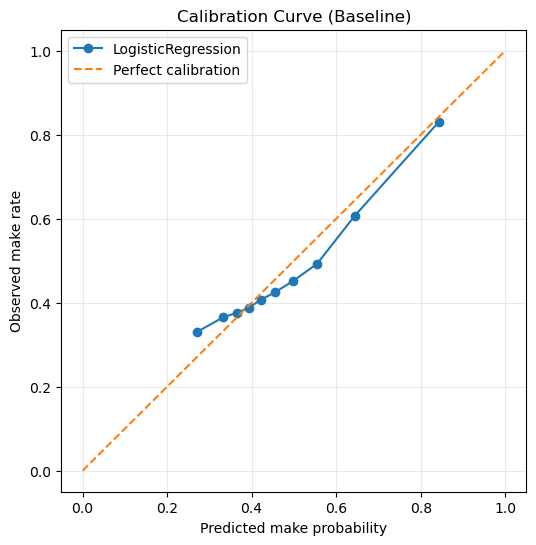

In [ ]:
# Baseline logistic model
logit_clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
    ]
)

logit_clf.fit(X_train, y_train)
logit_prob = logit_clf.predict_proba(X_test)[:, 1]

logit_metrics = evaluate_prob_model("LogisticRegression", y_test, logit_prob)
print(pd.Series(logit_metrics))

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, logit_prob, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="LogisticRegression")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Predicted make probability")
plt.ylabel("Observed make rate")
plt.title("Calibration Curve (Baseline)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Baseline Shot Samples (Detailed Context)

Random sample of 20 test shots with model inputs, player-specific predicted xFG/xPTS, league-average xFG/xPTS for the same shot context, and player training-history makes/attempts for that action type.

In [ ]:
# Build league-context xFG baselines from TRAIN data only
league_overall_fg = train_df["SHOT_MADE_FLAG"].mean()

league_ctx_full = (
    train_df.groupby(["SHOT_TYPE", "SHOT_ZONE_BASIC", "ACTION_TYPE", "distance_bin"], dropna=False)["SHOT_MADE_FLAG"]
    .mean()
    .rename("league_make_pct_full")
    .reset_index()
)
league_ctx_mid = (
    train_df.groupby(["SHOT_TYPE", "SHOT_ZONE_BASIC", "ACTION_TYPE"], dropna=False)["SHOT_MADE_FLAG"]
    .mean()
    .rename("league_make_pct_mid")
    .reset_index()
)
league_ctx_type = (
    train_df.groupby(["SHOT_TYPE"], dropna=False)["SHOT_MADE_FLAG"]
    .mean()
    .rename("league_make_pct_type")
    .reset_index()
)

# Player action-type history from training data (for that player's action type)
player_action_train_stats = (
    train_df.groupby(["PLAYER_ID", "ACTION_TYPE"], dropna=False)
    .agg(
        player_action_attempts_train=("SHOT_MADE_FLAG", "size"),
        player_action_makes_train=("SHOT_MADE_FLAG", "sum"),
    )
    .reset_index()
)
player_action_train_stats["player_action_fg_train"] = (
    player_action_train_stats["player_action_makes_train"]
    / player_action_train_stats["player_action_attempts_train"].clip(lower=1)
)

# Add baseline model probabilities to test shots
baseline_eval_df = test_df.copy()
baseline_eval_df["xfg_pct_player_specific"] = logit_prob
baseline_eval_df["xpts_player_specific"] = baseline_eval_df["xfg_pct_player_specific"] * baseline_eval_df["shot_value"]
baseline_eval_df["points_above_expected"] = baseline_eval_df["actual_points"] - baseline_eval_df["xpts_player_specific"]

# Merge league context with fallback hierarchy
baseline_eval_df = baseline_eval_df.merge(
    league_ctx_full,
    on=["SHOT_TYPE", "SHOT_ZONE_BASIC", "ACTION_TYPE", "distance_bin"],
    how="left",
)
baseline_eval_df = baseline_eval_df.merge(
    league_ctx_mid,
    on=["SHOT_TYPE", "SHOT_ZONE_BASIC", "ACTION_TYPE"],
    how="left",
)
baseline_eval_df = baseline_eval_df.merge(
    league_ctx_type,
    on=["SHOT_TYPE"],
    how="left",
)

baseline_eval_df["xfg_league_specific_shot"] = (
    baseline_eval_df["league_make_pct_full"]
    .fillna(baseline_eval_df["league_make_pct_mid"])
    .fillna(baseline_eval_df["league_make_pct_type"])
    .fillna(league_overall_fg)
)
baseline_eval_df["xpts_league_specific_shot"] = baseline_eval_df["xfg_league_specific_shot"] * baseline_eval_df["shot_value"]

# Merge player action-type makes/attempts from training history
baseline_eval_df = baseline_eval_df.merge(
    player_action_train_stats,
    on=["PLAYER_ID", "ACTION_TYPE"],
    how="left",
)
for c in ["player_action_attempts_train", "player_action_makes_train"]:
    baseline_eval_df[c] = baseline_eval_df[c].fillna(0).astype(int)
baseline_eval_df["player_action_fg_train"] = baseline_eval_df["player_action_fg_train"].fillna(league_overall_fg)

sample_cols = [
    "PLAYER_NAME", "TEAM_NAME", "GAME_ID",
    "SHOT_TYPE", "ACTION_TYPE", "SHOT_DISTANCE", "SHOT_ZONE_BASIC", "SHOT_ZONE_AREA", "SHOT_ZONE_RANGE",
    "distance_bin", "LOC_X", "LOC_Y", "abs_loc_x", "shot_angle",
    "is_corner_3", "is_above_break_3", "is_restricted_area", "is_midrange", "is_paint_non_ra", "is_deep_3",
    "is_home_team", "is_late_game",
    "SHOT_MADE_FLAG", "shot_value", "actual_points",
    "xfg_pct_player_specific", "xpts_player_specific", "points_above_expected",
    "xfg_league_specific_shot", "xpts_league_specific_shot",
    "player_action_makes_train", "player_action_attempts_train", "player_action_fg_train",
]

sample_20 = baseline_eval_df.sample(n=min(20, len(baseline_eval_df)), random_state=RANDOM_SEED)[sample_cols].copy()
display(sample_20.sort_values(["PLAYER_NAME", "GAME_ID", "SHOT_DISTANCE"]))

,PLAYER_NAME,TEAM_NAME,GAME_ID,SHOT_TYPE,ACTION_TYPE,SHOT_DISTANCE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,distance_bin,LOC_X,LOC_Y,abs_loc_x,shot_angle,is_corner_3,is_above_break_3,is_restricted_area,is_midrange,is_paint_non_ra,is_deep_3,is_home_team,is_late_game,SHOT_MADE_FLAG,shot_value,actual_points,xfg_pct_player_specific,xpts_player_specific,points_above_expected,xfg_league_specific_shot,xpts_league_specific_shot,player_action_makes_train,player_action_attempts_train,player_action_fg_train
188070,Austin Reaves,Los Angeles Lakers,22401055,3PT Field Goal,Jump Shot,24,Right Corner 3,Right Side(R),24+ ft.,24-27,240,11,240,2.624220,1,0,0,0,0,0,0.0,0,0,3,0,0.438747,1.316241,-1.316241,0.365161,1.095482,131,347,0.377522
156093,Buddy Hield,Golden State Warriors,22400875,2PT Field Goal,Fadeaway Jump Shot,10,In The Paint (Non-RA),Center(C),8-16 ft.,8-15,9,104,9,85.054033,0,0,0,0,1,0,0.0,0,0,2,0,0.492982,0.985965,-0.985965,0.425316,0.850633,11,17,0.647059
139929,CJ McCollum,New Orleans Pelicans,22400785,2PT Field Goal,Driving Floating Jump Shot,6,In The Paint (Non-RA),Center(C),Less Than 8 ft.,4-7,28,59,28,64.612094,0,0,0,0,1,0,1.0,1,0,2,0,0.427652,0.855305,-0.855305,0.427244,0.854488,96,196,0.489796
114834,Damian Lillard,Milwaukee Bucks,22400646,3PT Field Goal,Jump Shot,23,Left Corner 3,Left Side(L),24+ ft.,16-23,-237,-4,237,-179.033074,1,0,0,0,0,0,0.0,0,1,3,3,0.358797,1.076391,1.923609,0.389325,1.167974,105,315,0.333333
131903,Dante Exum,Dallas Mavericks,22400741,2PT Field Goal,Driving Dunk Shot,2,Restricted Area,Center(C),Less Than 8 ft.,0-3,7,21,7,71.565051,0,0,1,0,0,0,1.0,0,1,2,2,0.745039,1.490078,0.509922,0.823977,1.647954,4,6,0.666667
117100,Derrick Jones Jr.,LA Clippers,22400659,2PT Field Goal,Driving Floating Jump Shot,11,In The Paint (Non-RA),Center(C),8-16 ft.,8-15,-29,115,29,104.153413,0,0,0,0,1,0,0.0,0,1,2,2,0.372734,0.745468,1.254532,0.446731,0.893462,8,16,0.500000
97990,Devin Vassell,San Antonio Spurs,22400552,3PT Field Goal,Pullup Jump shot,27,Above the Break 3,Right Side Center(RC),24+ ft.,24-27,148,236,148,57.907409,0,1,0,0,0,0,0.0,0,0,3,0,0.250922,0.752766,-0.752766,0.343728,1.031184,162,409,0.396088
175191,Isaiah Hartenstein,Oklahoma City Thunder,22400982,2PT Field Goal,Cutting Layup Shot,1,Restricted Area,Center(C),Less Than 8 ft.,0-3,-10,13,10,127.568592,0,0,1,0,0,0,0.0,0,1,2,2,0.725065,1.450129,0.549871,0.739428,1.478856,26,35,0.742857
68112,James Harden,LA Clippers,22400385,2PT Field Goal,Step Back Jump shot,12,In The Paint (Non-RA),Center(C),8-16 ft.,8-15,-11,128,11,94.911788,0,0,0,0,1,0,0.0,0,1,2,2,0.398325,0.796650,1.203350,0.487654,0.975309,139,349,0.398281
105689,Jaylin Williams,Oklahoma City Thunder,22400595,2PT Field Goal,Layup Shot,1,Restricted Area,Center(C),Less Than 8 ft.,0-3,11,6,11,28.610460,0,0,1,0,0,0,1.0,0,0,2,0,0.487818,0.975636,-0.975636,0.560681,1.121362,3,9,0.333333


## 10) Stronger Model (XGBoost if available, else RandomForest)

Model          XGBClassifier
Accuracy             0.60803
ROC AUC             0.633966
Log Loss            0.674278
Brier Score         0.236403
dtype: object


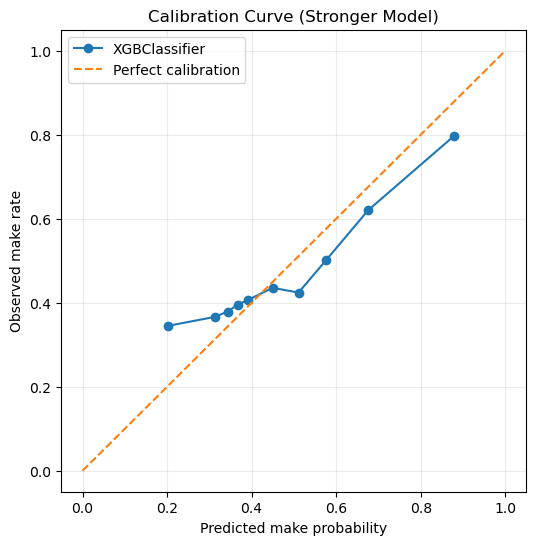

In [ ]:

strong_model_name = "XGBClassifier"
strong_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_SEED,
)


strong_clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", strong_model),
    ]
)

strong_clf.fit(X_train, y_train)
strong_prob = strong_clf.predict_proba(X_test)[:, 1]

strong_metrics = evaluate_prob_model(strong_model_name, y_test, strong_prob)
print(pd.Series(strong_metrics))

prob_true_s, prob_pred_s = calibration_curve(y_test, strong_prob, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot(prob_pred_s, prob_true_s, marker="o", label=strong_model_name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Predicted make probability")
plt.ylabel("Observed make rate")
plt.title("Calibration Curve (Stronger Model)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 11) Model Comparison

We choose the best model mainly on **Log Loss** and **Brier Score** because this is a probability model.

In [ ]:
comparison_df = pd.DataFrame([logit_metrics, strong_metrics])
comparison_df = comparison_df[["Model", "Accuracy", "ROC AUC", "Log Loss", "Brier Score"]]
comparison_df = comparison_df.sort_values(["Log Loss", "Brier Score"], ascending=[True, True]).reset_index(drop=True)

display(comparison_df)

best_model_name = comparison_df.iloc[0]["Model"]
best_clf = logit_clf if best_model_name == "LogisticRegression" else strong_clf
print("Selected best model:", best_model_name)

,Model,Accuracy,ROC AUC,Log Loss,Brier Score
0,LogisticRegression,0.615706,0.642774,0.647783,0.228947
1,XGBClassifier,0.608030,0.633966,0.674278,0.236403


Selected best model: LogisticRegression


## 12) Generate xPTS on Test Set

In [ ]:
test_pred = test_df.copy()
test_pred["xfg_pct_player_specific"] = best_clf.predict_proba(X_test)[:, 1]
test_pred["xpts_player_specific"] = test_pred["xfg_pct_player_specific"] * test_pred["shot_value"]
test_pred["points_above_expected"] = test_pred["actual_points"] - test_pred["xpts_player_specific"]

cols_show = [
    "PLAYER_NAME", "TEAM_NAME", "GAME_ID", "SHOT_TYPE", "ACTION_TYPE", "SHOT_DISTANCE",
    "SHOT_ZONE_BASIC", "SHOT_MADE_FLAG", "xfg_pct_player_specific", "xpts_player_specific", "actual_points", "points_above_expected"
]

display(test_pred[cols_show].head(20))

,PLAYER_NAME,TEAM_NAME,GAME_ID,SHOT_TYPE,ACTION_TYPE,SHOT_DISTANCE,SHOT_ZONE_BASIC,SHOT_MADE_FLAG,xfg_pct_player_specific,xpts_player_specific,actual_points,points_above_expected
0,Zaccharie Risacher,Atlanta Hawks,22400001,3PT Field Goal,Jump Shot,26,Above the Break 3,0,0.573801,1.721402,0,-1.721402
1,Jalen Johnson,Atlanta Hawks,22400001,2PT Field Goal,Driving Floating Bank Jump Shot,13,Mid-Range,0,0.457971,0.915943,0,-0.915943
2,Derrick White,Boston Celtics,22400001,3PT Field Goal,Jump Shot,28,Above the Break 3,0,0.389505,1.168515,0,-1.168515
3,Jalen Johnson,Atlanta Hawks,22400001,3PT Field Goal,Jump Shot,25,Above the Break 3,1,0.346324,1.038973,3,1.961027
4,Jaylen Brown,Boston Celtics,22400001,3PT Field Goal,Pullup Jump shot,27,Above the Break 3,1,0.379623,1.138870,3,1.861130
5,Jaylen Brown,Boston Celtics,22400001,3PT Field Goal,Jump Shot,24,Left Corner 3,0,0.410074,1.230222,0,-1.230222
6,Keaton Wallace,Atlanta Hawks,22400001,3PT Field Goal,Jump Shot,25,Above the Break 3,0,0.590876,1.772629,0,-1.772629
7,Clint Capela,Atlanta Hawks,22400001,2PT Field Goal,Putback Layup Shot,2,Restricted Area,1,0.582069,1.164138,2,0.835862
8,Jaylen Brown,Boston Celtics,22400001,2PT Field Goal,Driving Layup Shot,1,Restricted Area,1,0.724526,1.449052,2,0.550948
9,Zaccharie Risacher,Atlanta Hawks,22400001,2PT Field Goal,Cutting Layup Shot,1,Restricted Area,1,0.692319,1.384639,2,0.615361


## 13) Aggregate Analysis

In [ ]:
def aggregate_xpts(df: pd.DataFrame, group_cols):
    agg = (
        df.groupby(group_cols, dropna=False)
          .agg(
              shots=("SHOT_MADE_FLAG", "size"),
              actual_points=("actual_points", "sum"),
              expected_points=("xpts_player_specific", "sum"),
          )
          .reset_index()
    )
    agg["points_above_expected"] = agg["actual_points"] - agg["expected_points"]
    agg["average_xpts_per_shot"] = agg["expected_points"] / agg["shots"].clip(lower=1)
    agg["actual_points_per_shot"] = agg["actual_points"] / agg["shots"].clip(lower=1)
    return agg

player_summary = aggregate_xpts(test_pred, ["PLAYER_NAME"]).sort_values("shots", ascending=False)
team_summary = aggregate_xpts(test_pred, ["TEAM_NAME"]).sort_values("shots", ascending=False)
zone_summary = aggregate_xpts(test_pred, ["SHOT_ZONE_BASIC"]).sort_values("shots", ascending=False)
action_summary = aggregate_xpts(test_pred, ["ACTION_TYPE"]).sort_values("shots", ascending=False)
game_summary = aggregate_xpts(test_pred, ["GAME_ID"]).sort_values("shots", ascending=False)

print("Player summary")
display(player_summary.head(15))

print("Team summary")
display(team_summary.head(15))

print("Shot zone summary")
display(zone_summary.head(15))

print("Action type summary")
display(action_summary.head(15))

print("Game summary")
display(game_summary.head(15))

Player summary


,PLAYER_NAME,shots,actual_points,expected_points,points_above_expected,average_xpts_per_shot,actual_points_per_shot
487,Shai Gilgeous-Alexander,1656,1883,1842.238881,40.761119,1.112463,1.137077
29,Anthony Edwards,1612,1762,1605.582550,156.417450,0.996019,1.093052
261,Jayson Tatum,1465,1574,1497.885045,76.114955,1.022447,1.074403
69,Cade Cunningham,1457,1517,1412.153298,104.846702,0.969220,1.041181
227,Jalen Green,1437,1450,1330.642833,119.357167,0.925987,1.009047
141,Devin Booker,1420,1491,1568.991044,-77.991044,1.104923,1.050000
537,Tyler Herro,1378,1553,1541.095253,11.904747,1.118356,1.126996
520,Trae Young,1376,1350,1335.727542,14.272458,0.970732,0.981105
420,Nikola Jokić,1364,1710,1689.961372,20.038628,1.238975,1.253666
149,Donovan Mitchell,1320,1403,1463.585102,-60.585102,1.108777,1.062879


Team summary


,TEAM_NAME,shots,actual_points,expected_points,points_above_expected,average_xpts_per_shot,actual_points_per_shot
10,Houston Rockets,7659,8006,7899.845539,106.154461,1.031446,1.045306
14,Memphis Grizzlies,7654,8481,8620.765980,-139.765980,1.126309,1.108048
20,Oklahoma City Thunder,7600,8512,8836.248008,-324.248008,1.162664,1.120000
4,Chicago Bulls,7545,8352,8371.310798,-19.310798,1.109518,1.106958
0,Atlanta Hawks,7528,8219,8486.942972,-267.942972,1.127383,1.091791
27,Toronto Raptors,7462,7797,8627.572931,-830.572931,1.156201,1.044894
5,Cleveland Cavaliers,7444,8607,8425.699547,181.300453,1.131878,1.156233
9,Golden State Warriors,7412,7948,8439.830089,-491.830089,1.138671,1.072315
24,Portland Trail Blazers,7396,7707,7761.271377,-54.271377,1.049388,1.042050
25,Sacramento Kings,7385,8090,7947.262593,142.737407,1.076136,1.095464


Shot zone summary


,SHOT_ZONE_BASIC,shots,actual_points,expected_points,points_above_expected,average_xpts_per_shot,actual_points_per_shot
0,Above the Break 3,68358,72427,77858.379763,-5431.379763,1.138980,1.059525
5,Restricted Area,61190,81206,81220.567099,-14.567099,1.327350,1.327112
2,In The Paint (Non-RA),44475,39468,39521.606941,-53.606941,0.888625,0.887420
4,Mid-Range,21402,17852,17943.271457,-91.271457,0.838392,0.834128
3,Left Corner 3,12188,14118,14781.934458,-663.934458,1.212827,1.158352
6,Right Corner 3,11397,13329,13850.401628,-521.401628,1.215267,1.169518
1,Backcourt,517,36,31.059660,4.940340,0.060077,0.069632


Action type summary


,ACTION_TYPE,shots,actual_points,expected_points,points_above_expected,average_xpts_per_shot,actual_points_per_shot
22,Jump Shot,63033,69190,73104.156703,-3914.156703,1.159776,1.097679
24,Pullup Jump shot,25568,23911,25100.981853,-1189.981853,0.981734,0.935192
11,Driving Layup Shot,18930,17820,17735.342559,84.657441,0.936891,0.941363
9,Driving Floating Jump Shot,13437,11494,11709.790716,-215.790716,0.871459,0.855399
39,Step Back Jump shot,12361,11901,12718.781733,-817.781733,1.028944,0.962786
34,Running Layup Shot,7515,8764,8681.793130,82.206870,1.155262,1.166201
33,Running Jump Shot,6853,7804,8246.521497,-442.521497,1.203345,1.138771
7,Driving Finger Roll Layup Shot,6036,7630,7395.184706,234.815294,1.225180,1.264082
4,Cutting Layup Shot,5811,7850,7883.126439,-33.126439,1.356587,1.350886
41,Tip Layup Shot,4867,4670,4711.627322,-41.627322,0.968076,0.959523


Game summary


,GAME_ID,shots,actual_points,expected_points,points_above_expected,average_xpts_per_shot,actual_points_per_shot
1188,22401189,234,212,279.479086,-67.479086,1.194355,0.905983
739,22400740,221,225,251.433663,-26.433663,1.137709,1.018100
413,22400414,217,246,263.785237,-17.785237,1.215600,1.133641
931,22400932,214,194,265.210323,-71.210323,1.239301,0.906542
118,22400119,213,222,230.061700,-8.061700,1.080102,1.042254
240,22400241,212,206,231.405185,-25.405185,1.091534,0.971698
483,22400484,212,199,235.388877,-36.388877,1.110325,0.938679
272,22400273,212,204,237.738162,-33.738162,1.121406,0.962264
107,22400108,211,231,238.310227,-7.310227,1.129432,1.094787
500,22400501,210,200,214.454760,-14.454760,1.021213,0.952381


## 14) Game-Level xPTS Example

This shot-based flow compares cumulative actual points vs cumulative expected points by team for one test game.

Note: this reconstruction uses shot attempts only and may not fully match official scoreboard totals because free throws and some possession context are not included.

## 14) Player-Specific Diagnostics

In [41]:
diag = test_pred.copy()

# 1) Curry vs Giannis pull-up 3 comparison if available, otherwise top pull-up examples
pullup_3 = diag[(diag["ACTION_TYPE"].astype(str).str.contains("pull", case=False, na=False)) & (diag["shot_value"] == 3)].copy()

players_focus = ["Stephen Curry", "Giannis Antetokounmpo"]
focus_df = pullup_3[pullup_3["PLAYER_NAME"].isin(players_focus)]
if focus_df.empty:
    print("Curry/Giannis pull-up 3 subset unavailable; showing top pull-up 3 player examples.")
    focus_df = (
        pullup_3.groupby(["PLAYER_NAME", "ACTION_TYPE"], dropna=False)
        .agg(shots=("SHOT_MADE_FLAG", "size"), avg_xfg=("xfg_pct_player_specific", "mean"), fg_pct=("SHOT_MADE_FLAG", "mean"))
        .reset_index()
        .sort_values("shots", ascending=False)
        .head(15)
    )
else:
    focus_df = (
        focus_df.groupby(["PLAYER_NAME", "ACTION_TYPE"], dropna=False)
        .agg(shots=("SHOT_MADE_FLAG", "size"), avg_xfg=("xfg_pct_player_specific", "mean"), fg_pct=("SHOT_MADE_FLAG", "mean"))
        .reset_index()
    )

display(focus_df)

# 2) Top 20 players by shots with avg xFG / actual FG / points above expected
top_players_diag = (
    diag.groupby(["PLAYER_ID", "PLAYER_NAME"], dropna=False)
    .agg(
        shots=("SHOT_MADE_FLAG", "size"),
        avg_xfg=("xfg_pct_player_specific", "mean"),
        actual_fg_pct=("SHOT_MADE_FLAG", "mean"),
        actual_points=("actual_points", "sum"),
        expected_points=("xpts_player_specific", "sum"),
    )
    .reset_index()
)
top_players_diag["points_above_expected"] = top_players_diag["actual_points"] - top_players_diag["expected_points"]
display(top_players_diag.sort_values("shots", ascending=False).head(20))

# 3) By action type diagnostics
action_diag = (
    diag.groupby("ACTION_TYPE", dropna=False)
    .agg(
        shots=("SHOT_MADE_FLAG", "size"),
        avg_xfg=("xfg_pct_player_specific", "mean"),
        actual_fg_pct=("SHOT_MADE_FLAG", "mean"),
    )
    .reset_index()
    .sort_values("shots", ascending=False)
)
display(action_diag.head(25))

# Rim and midrange specialist examples
rim_examples = (
    diag[diag["is_restricted_area"] == 1]
    .groupby("PLAYER_NAME", dropna=False)
    .agg(shots=("SHOT_MADE_FLAG", "size"), avg_xfg=("xfg_pct_player_specific", "mean"), fg_pct=("SHOT_MADE_FLAG", "mean"))
    .reset_index()
    .sort_values("shots", ascending=False)
    .head(12)
)
mid_examples = (
    diag[diag["is_midrange"] == 1]
    .groupby("PLAYER_NAME", dropna=False)
    .agg(shots=("SHOT_MADE_FLAG", "size"), avg_xfg=("xfg_pct_player_specific", "mean"), fg_pct=("SHOT_MADE_FLAG", "mean"))
    .reset_index()
    .sort_values("shots", ascending=False)
    .head(12)
)
print("High-volume rim attempt examples")
display(rim_examples)
print("High-volume midrange attempt examples")
display(mid_examples)

# 4) Closest defender profile leaders (open 10ft+ 3P smoothed proxy)
if "player_10ft_open_3p_smoothed" in diag.columns:
    leader_cols = ["PLAYER_ID", "PLAYER_NAME", "player_10ft_open_3p_smoothed", "player_10ft_open_freq"]
    leaders = diag[leader_cols].drop_duplicates()
    if "player_10ft_open_freq" in leaders.columns:
        leaders = leaders[leaders["player_10ft_open_freq"].fillna(0) >= 0.05]
    leaders = leaders.sort_values("player_10ft_open_3p_smoothed", ascending=False).head(20)
    display(leaders)
else:
    print("Closest defender 10ft+ derived features unavailable in this run.")

,PLAYER_NAME,ACTION_TYPE,shots,avg_xfg,fg_pct
0,Giannis Antetokounmpo,Pullup Jump shot,39,0.221174,0.256410
1,Stephen Curry,Pullup Jump shot,228,0.335001,0.364035
2,Stephen Curry,Running Pull-Up Jump Shot,38,0.345795,0.368421


,PLAYER_ID,PLAYER_NAME,shots,avg_xfg,actual_fg_pct,actual_points,expected_points,points_above_expected
161,1628983,Shai Gilgeous-Alexander,1656,0.508098,0.519324,1883,1842.238881,40.761119
238,1630162,Anthony Edwards,1612,0.419872,0.447270,1762,1605.582550,156.417450
124,1628369,Jayson Tatum,1465,0.435312,0.451877,1574,1497.885045,76.114955
333,1630595,Cade Cunningham,1457,0.436026,0.469458,1517,1412.153298,104.846702
270,1630224,Jalen Green,1437,0.399746,0.423104,1450,1330.642833,119.357167
85,1626164,Devin Booker,1420,0.479692,0.460563,1491,1568.991044,-77.991044
215,1629639,Tyler Herro,1378,0.463981,0.472424,1553,1541.095253,11.904747
183,1629027,Trae Young,1376,0.410802,0.411337,1350,1335.727542,14.272458
75,203999,Nikola Jokić,1364,0.576612,0.576246,1710,1689.961372,20.038628
128,1628378,Donovan Mitchell,1320,0.464792,0.443182,1403,1463.585102,-60.585102


,ACTION_TYPE,shots,avg_xfg,actual_fg_pct
22,Jump Shot,63033,0.394976,0.373868
24,Pullup Jump shot,25568,0.392616,0.375821
11,Driving Layup Shot,18930,0.468445,0.470681
9,Driving Floating Jump Shot,13437,0.435213,0.427402
39,Step Back Jump shot,12361,0.388194,0.368579
34,Running Layup Shot,7515,0.577631,0.583100
33,Running Jump Shot,6853,0.405278,0.384211
7,Driving Finger Roll Layup Shot,6036,0.612590,0.632041
4,Cutting Layup Shot,5811,0.678293,0.675443
41,Tip Layup Shot,4867,0.484038,0.479762


High-volume rim attempt examples


,PLAYER_NAME,shots,avg_xfg,fg_pct
179,Giannis Antetokounmpo,749,0.800778,0.748999
307,Karl-Anthony Towns,514,0.669889,0.669261
202,Ivica Zubac,502,0.677326,0.713147
19,Alperen Sengun,481,0.634985,0.648649
145,Domantas Sabonis,475,0.725206,0.694737
223,Jalen Duren,434,0.717168,0.728111
168,Evan Mobley,432,0.743947,0.761574
414,Nikola Jokić,431,0.734401,0.719258
245,Jarrett Allen,429,0.747101,0.771562
87,Christian Braun,428,0.642518,0.714953


High-volume midrange attempt examples


,PLAYER_NAME,shots,avg_xfg,fg_pct
118,DeMar DeRozan,640,0.403759,0.457813
441,Shai Gilgeous-Alexander,348,0.453623,0.500000
128,Devin Booker,325,0.487563,0.516923
298,Kevin Durant,286,0.565112,0.531469
163,Giannis Antetokounmpo,283,0.307695,0.441696
212,Jamal Murray,278,0.416679,0.449640
201,Jalen Brunson,227,0.407265,0.449339
399,Paolo Banchero,218,0.372498,0.417431
203,Jalen Green,218,0.348784,0.362385
325,LeBron James,218,0.317192,0.435780


,PLAYER_ID,PLAYER_NAME,player_10ft_open_3p_smoothed,player_10ft_open_freq
0,1642258,Zaccharie Risacher,0.473261,0.322902
7012,1642354,KJ Simpson,0.473261,0.346154
6325,1630699,MarJon Beauchamp,0.473261,0.395604
6470,1642265,Rob Dillingham,0.473261,0.460177
6628,1631117,Walker Kessler,0.473261,0.105263
6804,201142,Kevin Durant,0.473261,0.320747
6815,1629060,Rui Hachimura,0.473261,0.436782
6964,1629637,Jaxson Hayes,0.473261,0.241135
7298,1642281,Jaylon Tyson,0.473261,0.438849
6289,202710,Jimmy Butler III,0.473261,0.410858


Example GAME_ID: 22400001


,GAME_ID,GAME_EVENT_ID,PERIOD,seconds_elapsed_in_game,TEAM_NAME,SHOT_TYPE,SHOT_MADE_FLAG,actual_points,xpts_player_specific,actual_cum_points_team,xpts_cum_team
0,22400001,7,1,17,Atlanta Hawks,3PT Field Goal,0,0,1.721402,0.0,1.721402
1,22400001,10,1,22,Atlanta Hawks,2PT Field Goal,0,0,0.915943,0.0,2.637345
2,22400001,12,1,36,Boston Celtics,3PT Field Goal,0,0,1.168515,0.0,1.168515
3,22400001,21,1,70,Atlanta Hawks,3PT Field Goal,1,3,1.038973,3.0,3.676318
4,22400001,23,1,85,Boston Celtics,3PT Field Goal,1,3,1.138870,3.0,2.307385
5,22400001,31,1,114,Boston Celtics,3PT Field Goal,0,0,1.230222,3.0,3.537607
6,22400001,34,1,133,Atlanta Hawks,3PT Field Goal,0,0,1.772629,3.0,5.448947
7,22400001,36,1,136,Atlanta Hawks,2PT Field Goal,1,2,1.164138,5.0,6.613085
8,22400001,37,1,145,Boston Celtics,2PT Field Goal,1,2,1.449052,5.0,4.986659
9,22400001,39,1,157,Atlanta Hawks,2PT Field Goal,1,2,1.384639,7.0,7.997724


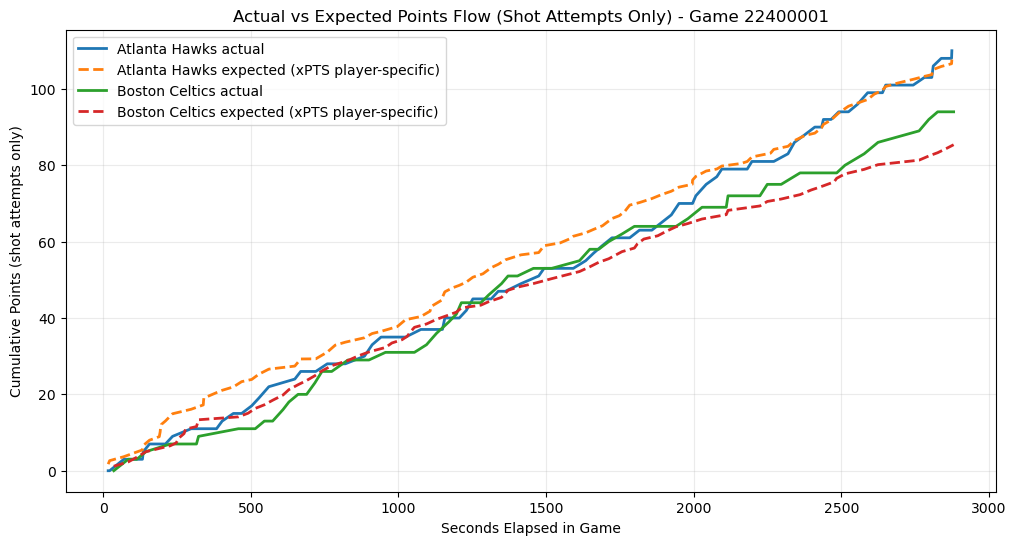

Note: This shot-based flow does not include free throws unless play-by-play is joined.


In [42]:
example_game_id = test_pred["GAME_ID"].dropna().astype(str).iloc[0]
print("Example GAME_ID:", example_game_id)

game_flow = test_pred[test_pred["GAME_ID"].astype(str) == example_game_id].copy()
game_flow = game_flow.sort_values(["PERIOD", "seconds_elapsed_in_game", "GAME_EVENT_ID"], na_position="last")

# Keep teams in deterministic order
teams_in_game = game_flow["TEAM_NAME"].dropna().unique().tolist()

for tm in teams_in_game:
    mask = game_flow["TEAM_NAME"] == tm
    game_flow.loc[mask, "actual_cum_points_team"] = game_flow.loc[mask, "actual_points"].cumsum()
    game_flow.loc[mask, "xpts_cum_team"] = game_flow.loc[mask, "xpts_player_specific"].cumsum()

show_cols = [
    "GAME_ID", "GAME_EVENT_ID", "PERIOD", "seconds_elapsed_in_game", "TEAM_NAME",
    "SHOT_TYPE", "SHOT_MADE_FLAG", "actual_points", "xpts_player_specific", "actual_cum_points_team", "xpts_cum_team"
]
display(game_flow[show_cols].head(30))

plt.figure(figsize=(12, 6))
for tm in teams_in_game:
    df_tm = game_flow[game_flow["TEAM_NAME"] == tm].sort_values(["seconds_elapsed_in_game", "GAME_EVENT_ID"])
    plt.plot(df_tm["seconds_elapsed_in_game"], df_tm["actual_cum_points_team"], label=f"{tm} actual", linewidth=2)
    plt.plot(df_tm["seconds_elapsed_in_game"], df_tm["xpts_cum_team"], linestyle="--", label=f"{tm} expected (xPTS player-specific)", linewidth=2)

plt.xlabel("Seconds Elapsed in Game")
plt.ylabel("Cumulative Points (shot attempts only)")
plt.title(f"Actual vs Expected Points Flow (Shot Attempts Only) - Game {example_game_id}")
plt.legend()
plt.grid(alpha=0.25)
plt.show()
print("Note: This shot-based flow does not include free throws unless play-by-play is joined.")

## 15) Shot Map Visualization

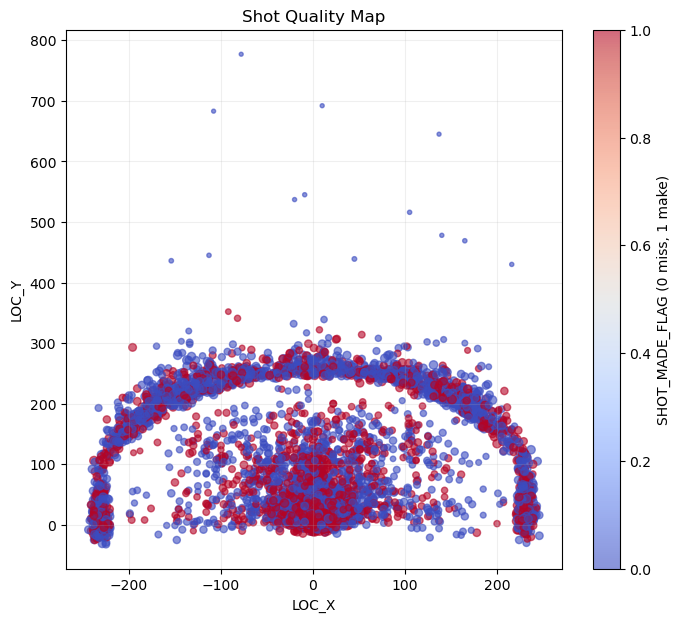

In [43]:
sample_for_map = test_pred.sample(n=min(5000, len(test_pred)), random_state=RANDOM_SEED).copy()

plt.figure(figsize=(8, 7))
scatter = plt.scatter(
    sample_for_map["LOC_X"],
    sample_for_map["LOC_Y"],
    c=sample_for_map["SHOT_MADE_FLAG"],
    s=(sample_for_map["xpts_player_specific"].fillna(0.2) * 18) + 8,
    alpha=0.6,
    cmap="coolwarm",
)
plt.colorbar(scatter, label="SHOT_MADE_FLAG (0 miss, 1 make)")
plt.xlabel("LOC_X")
plt.ylabel("LOC_Y")
plt.title("Shot Quality Map")
plt.grid(alpha=0.2)
plt.show()

## 16) Save Processed Output and Model

In [ ]:
# Save shot-level predictions
export_cols = [
    "GAME_ID", "GAME_EVENT_ID", "PLAYER_ID", "PLAYER_NAME", "TEAM_ID", "TEAM_NAME", "SEASON",
    "SHOT_TYPE", "ACTION_TYPE", "SHOT_ZONE_BASIC", "SHOT_ZONE_AREA", "SHOT_ZONE_RANGE",
    "SHOT_DISTANCE", "LOC_X", "LOC_Y", "SHOT_MADE_FLAG", "shot_value", "actual_points",
    "xfg_pct_player_specific", "xpts_player_specific", "points_above_expected",
    "player_overall_fg_smoothed", "player_2pt_fg_smoothed", "player_3pt_fg_smoothed",
    "player_zone_fg_smoothed", "player_action_fg_smoothed", "player_zone_action_fg_smoothed",
    "player_distance_bin_fg_smoothed", "player_rim_fg_smoothed", "player_midrange_fg_smoothed",
    "player_corner_3_fg_smoothed", "player_above_break_3_fg_smoothed", "player_deep_3_fg_smoothed",
    "player_avg_shot_distance", "player_3pa_rate", "player_rim_frequency", "player_midrange_frequency",
    "player_corner_3_frequency", "player_pullup_frequency",
    "player_all_very_tight_fg_smoothed", "player_all_tight_fg_smoothed", "player_all_open_fg_smoothed",
    "player_all_wide_open_fg_smoothed", "player_10ft_very_tight_fg_smoothed", "player_10ft_tight_fg_smoothed",
    "player_10ft_open_fg_smoothed", "player_10ft_wide_open_fg_smoothed",
    "player_all_very_tight_freq", "player_all_tight_freq", "player_all_open_freq", "player_all_wide_open_freq",
    "player_10ft_very_tight_freq", "player_10ft_tight_freq", "player_10ft_open_freq", "player_10ft_wide_open_freq",
]

for c in export_cols:
    if c not in test_pred.columns:
        test_pred[c] = np.nan

test_pred[export_cols].to_csv(PREDS_PATH, index=False)
print(f"Saved predictions to {PREDS_PATH}")

joblib.dump(best_clf, MODEL_PATH)
print(f"Saved model to {MODEL_PATH}")

## 17) Interpretation, Limitations, and Next Steps

### What this player-specific model predicts
Given this player’s historical smoothed skill profile and this shot context, the model predicts the probability the shot goes in (`xfg_pct_player_specific`).

### Why smoothing is used
- Raw player percentages can be misleading with small samples.
- Smoothing pulls low-volume splits toward league average.
- Larger-sample player splits are trusted more.

### Closest defender profile features
- These are player-level aggregate profile features from `PlayerDashPtShots`.
- They are not exact shot-level defender distance labels for each attempt.
- They help capture whether a player generally performs better/worse vs contested or open looks.

### What this model does well
- Uses training-season-only priors to avoid leakage into test season.
- Produces per-shot player-specific make probabilities (`xfg_pct_player_specific`) and expected points (`xpts_player_specific`).
- Supports player/team/zone/action aggregation and game-flow expected-vs-actual shot scoring views.

### Key limitations
- No true shot-level defender distance attached to each shot event.
- No true shot clock from `ShotChartDetail`.
- No player tracking pose/velocity data.
- Does not perfectly recreate NBA official xFG% methods.
- Shot-only game flow misses free throws unless play-by-play is joined.

### Next steps
- Join play-by-play using `GAME_ID` + `GAME_EVENT_ID`.
- Add score margin and possession context.
- Add passer/assist context and expected assist points.
- Add richer tracking-derived priors where available.
- Build an interactive Streamlit dashboard.
- Compare actual score vs expected score for selected games.